<a href="https://colab.research.google.com/github/gamuchiraimapear/HASTS211-ASSIGNMENTS/blob/main/Gamuchirai_Mapiye_R2420904assignment_3_cointegration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gamuchirai Mapiye R2420904 — Non-Stationarity, Cointegration & Equilibrium Modeling
### Dataset: Apple Inc. (AAPL), Microsoft (MSFT), NASDAQ-100 ETF (QQQ)
**Period:** January 1, 2018 – December 31, 2025 | **Frequency:** Daily

---

## 1. Definition

### 1.1 Non-Stationarity
A time series $y_t$ is **non-stationary** if its statistical properties (mean, variance, autocovariance) depend on time. Formally, a series contains a **unit root** if:

$$y_t = \\phi y_{t-1} + \\varepsilon_t, \\quad \\phi = 1$$

where $\\varepsilon_t \\sim \\text{i.i.d.}(0, \\sigma^2)$. When $\\phi = 1$, shocks are permanent and the series is said to be integrated of order one, denoted $I(1)$.

### 1.2 Cointegration
Two or more $I(1)$ series $\\mathbf{y}_t = (y_{1t}, y_{2t}, \\ldots, y_{kt})'$ are **cointegrated** (Engle & Granger, 1987) if there exists a vector $\\boldsymbol{\\beta}$ such that the linear combination:

$$z_t = \\boldsymbol{\\beta}' \\mathbf{y}_t$$

is stationary, i.e., $z_t \\sim I(0)$. The vector $\\boldsymbol{\\beta}$ is the **cointegrating vector**, and $z_t$ is the **equilibrium error**.

### 1.3 Vector Error Correction Model (VECM)
When cointegration is present, the short-run dynamics can be represented by a VECM:

$$\\Delta \\mathbf{y}_t = \\boldsymbol{\\alpha} z_{t-1} + \\sum_{i=1}^{p-1} \\boldsymbol{\\Gamma}_i \\Delta \\mathbf{y}_{t-i} + \\boldsymbol{\\varepsilon}_t$$

where:
- $\\Delta \\mathbf{y}_t$ = first differences of the price series (returns)
- $z_{t-1} = \\boldsymbol{\\beta}' \\mathbf{y}_{t-1}$ = lagged equilibrium error (error-correction term)
- $\\boldsymbol{\\alpha}$ = adjustment (loading) coefficients — speed of reversion to equilibrium
- $\\boldsymbol{\\Gamma}_i$ = short-run dynamic coefficient matrices
- $\\boldsymbol{\\varepsilon}_t$ = white noise disturbances

### 1.4 Johansen Trace Test
The number of cointegrating relationships $r$ is determined by the **Johansen (1991) trace statistic**:

$$\\lambda_{\\text{trace}}(r) = -T \\sum_{i=r+1}^{k} \\ln(1 - \\hat{\\lambda}_i)$$

where $\\hat{\\lambda}_i$ are the ordered eigenvalues of the concentration matrix and $T$ is the sample size.

---

## 2. Description

Non-stationarity in financial time series means that prices wander over time without reverting to a fixed mean, making standard regression unreliable unless a stable long-run relationship (cointegration) can be identified. Cointegration allows us to model both the short-run fluctuations and the long-run equilibrium that anchors prices together — capturing the idea that economically linked assets cannot drift apart indefinitely.

### Why AAPL, MSFT, and QQQ?
- All three are large-cap technology assets driven by common macro factors (interest rates, earnings cycles, risk appetite).
- Prices are individually $I(1)$ but may share a common stochastic trend, making cointegration plausible.
- A long-run equilibrium between these assets has practical applications for **pairs trading** and **index arbitrage**.

---
## 3. Demonstration — Data Import & Structure

In [ ]:
# Install dependencies (run once in Colab)
!pip install yfinance statsmodels --quiet

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import yfinance as yf
from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
# sns.set_style is compatible with all seaborn versions
sns.set_style('whitegrid')
sns.set_palette('tab10')

COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c']

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [ ]:
# Download data via yfinance API
TICKERS = ['AAPL', 'MSFT', 'QQQ']
START   = '2018-01-01'
END     = '2025-12-31'

raw = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)

# Handle both old yfinance (flat columns) and new yfinance (MultiIndex columns)
if isinstance(raw.columns, pd.MultiIndex):
    # New yfinance >= 0.2: columns are MultiIndex (field, ticker)
    prices = raw['Close'].copy()
    prices.columns = [str(c).strip() for c in prices.columns]
else:
    # Old yfinance: flat columns named e.g. 'AAPL', 'MSFT', 'QQQ' under 'Close'
    prices = raw.copy()
    prices.columns = [str(c).strip() for c in prices.columns]
    # Keep only AAPL, MSFT, QQQ columns if they exist
    available = [c for c in ['AAPL', 'MSFT', 'QQQ'] if c in prices.columns]
    prices = prices[available]

prices.index = pd.to_datetime(prices.index)
prices       = prices.dropna()

# Ensure correct column order
prices = prices[['AAPL', 'MSFT', 'QQQ']]

print(f'Shape         : {prices.shape}')
print(f'Date range    : {prices.index[0].date()} to {prices.index[-1].date()}')
print(f'Columns       : {list(prices.columns)}')
prices.head()

Shape         : (2010, 3)
Date range    : 2018-01-02 to 2025-12-30
Columns       : ['AAPL', 'MSFT', 'QQQ']


,AAPL,MSFT,QQQ
Date,,,
2018-01-02,40.304173,78.870361,150.222153
2018-01-03,40.297150,79.237396,151.681839
2018-01-04,40.484337,79.934807,151.947205
2018-01-05,40.945267,80.925850,153.473190
2018-01-08,40.793186,81.008438,154.070343


In [ ]:
# Basic descriptive statistics
print('=== Descriptive Statistics (Closing Prices) ===')
print(prices.describe().round(2))

=== Descriptive Statistics (Closing Prices) ===
          AAPL     MSFT      QQQ
count  2010.00  2010.00  2010.00
mean    135.32   263.48   321.65
std      66.70   125.59   128.23
min      33.77    78.01   137.16
25%      64.32   145.36   195.23
50%     142.80   250.85   309.10
75%     182.69   368.22   401.64
max     285.92   539.83   634.15


---
## 4. Diagram — Exploratory Plots

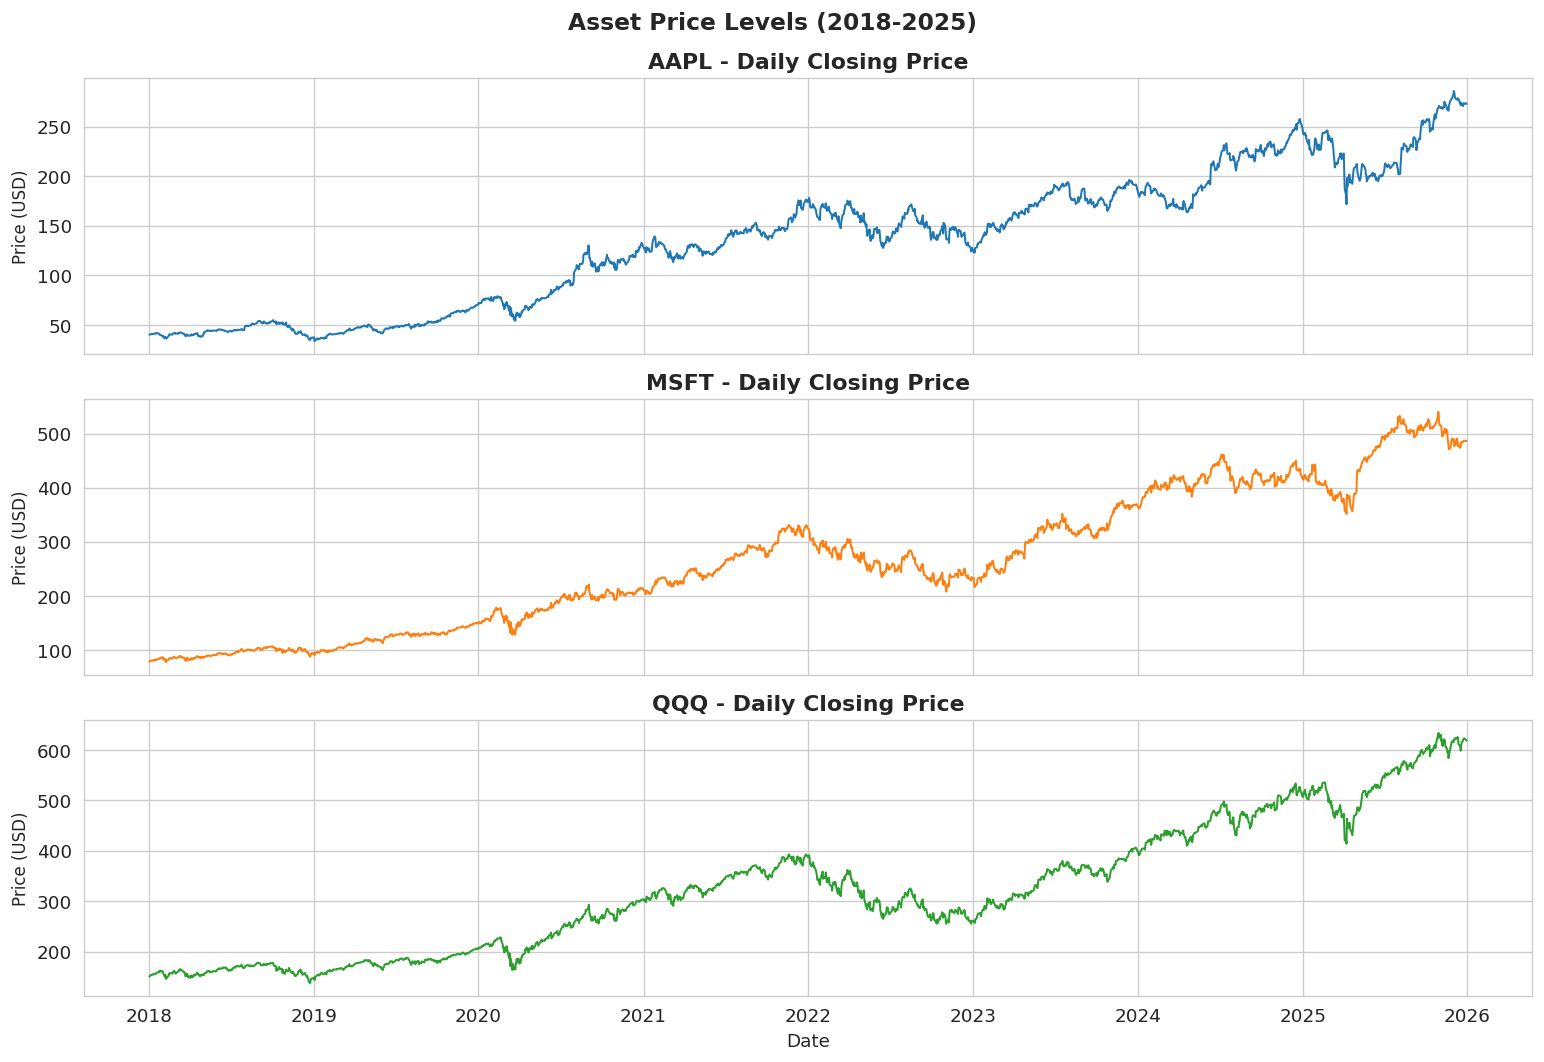

In [ ]:
# 4.1  Price levels over time
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

for ax, col, color in zip(axes, prices.columns, COLORS):
    ax.plot(prices.index, prices[col], color=color, linewidth=1.2)
    ax.set_ylabel('Price (USD)', fontsize=10)
    ax.set_title(f'{col} - Daily Closing Price', fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[-1].set_xlabel('Date')
plt.suptitle('Asset Price Levels (2018-2025)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

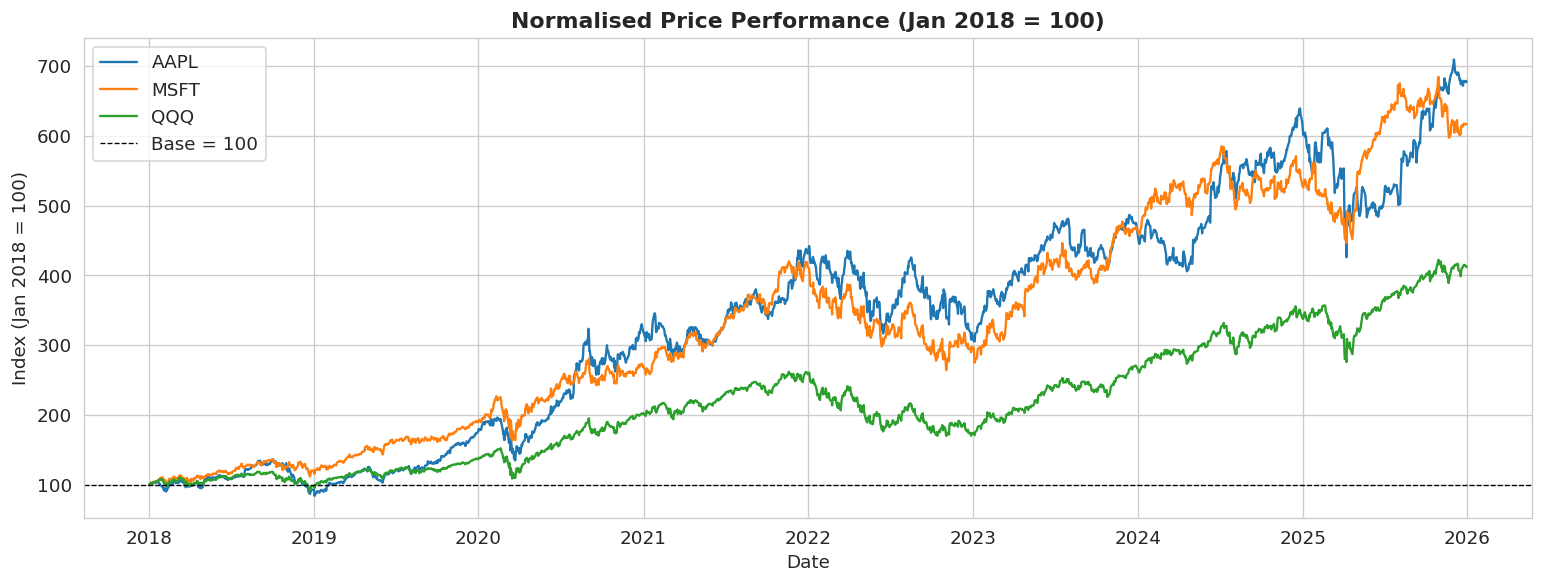

In [ ]:
# 4.2  Normalised prices (rebased to 100)
rebased = (prices / prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(13, 5))
for col, color in zip(rebased.columns, COLORS):
    ax.plot(rebased.index, rebased[col], label=col, color=color, linewidth=1.4)

ax.axhline(100, color='black', linestyle='--', linewidth=0.8, label='Base = 100')
ax.set_title('Normalised Price Performance (Jan 2018 = 100)', fontweight='bold')
ax.set_ylabel('Index (Jan 2018 = 100)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

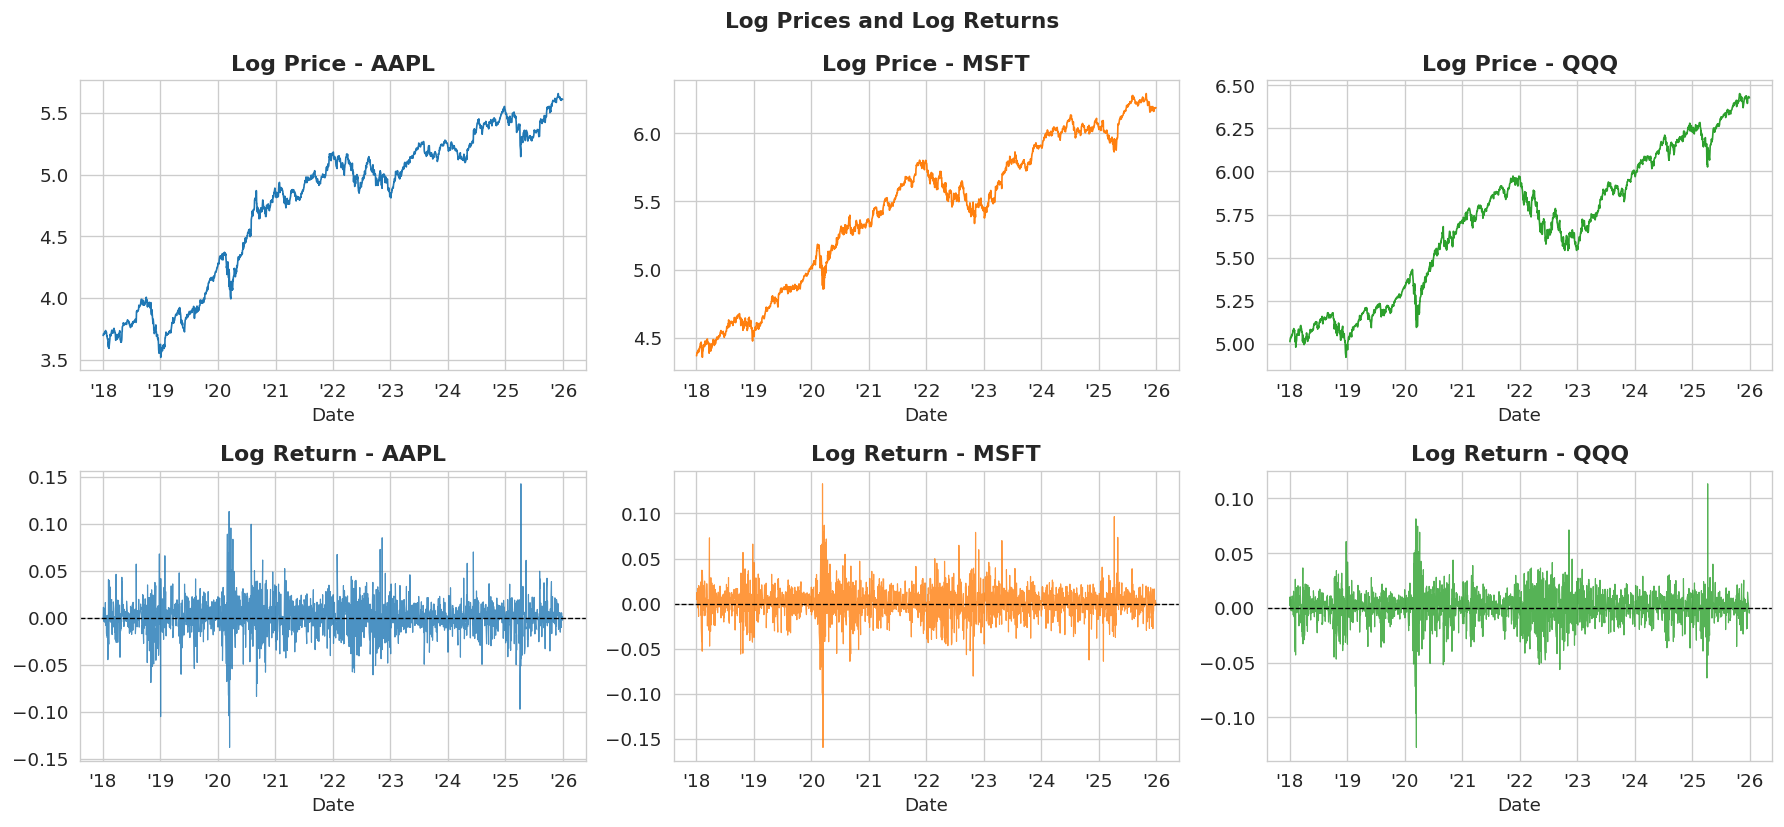

In [ ]:
# 4.3  Log-prices and log-returns
log_prices  = np.log(prices)
log_returns = log_prices.diff().dropna()

fig, axes = plt.subplots(2, 3, figsize=(15, 7))

for i, (col, color) in enumerate(zip(prices.columns, COLORS)):
    axes[0, i].plot(log_prices.index, log_prices[col], color=color, linewidth=1)
    axes[0, i].set_title(f'Log Price - {col}', fontweight='bold')
    axes[0, i].set_xlabel('Date')
    axes[0, i].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    axes[1, i].plot(log_returns.index, log_returns[col], color=color, linewidth=0.7, alpha=0.8)
    axes[1, i].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1, i].set_title(f'Log Return - {col}', fontweight='bold')
    axes[1, i].set_xlabel('Date')
    axes[1, i].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

plt.suptitle('Log Prices and Log Returns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

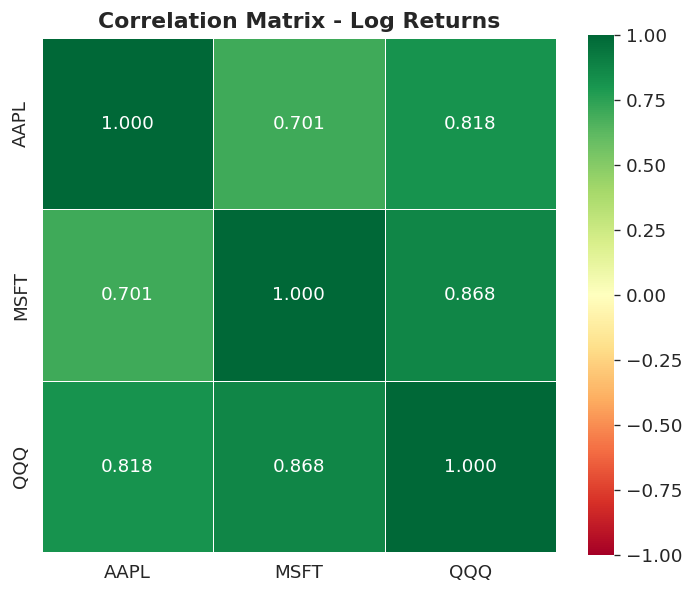

In [ ]:
# 4.4  Correlation heatmap of log returns
fig, ax = plt.subplots(figsize=(6, 5))
corr = log_returns.corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, square=True)
ax.set_title('Correlation Matrix - Log Returns', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Demonstration — Unit Root Testing (ADF)

In [ ]:
def adf_summary(series, name, maxlag=20):
    """Run ADF test and return results as a dict."""
    result = adfuller(series.dropna(), maxlag=maxlag, autolag='AIC')
    return {
        'Series'        : name,
        'ADF Statistic' : round(result[0], 4),
        'p-value'       : round(result[1], 4),
        'Lags Used'     : result[2],
        '1% CV'         : round(result[4]['1%'], 3),
        '5% CV'         : round(result[4]['5%'], 3),
        'Unit Root?'    : 'Yes' if result[1] > 0.05 else 'No'
    }

rows = []
for col in log_prices.columns:
    rows.append(adf_summary(log_prices[col],  f'{col} log-level'))
    rows.append(adf_summary(log_returns[col], f'{col} log-return (diff)'))

adf_df = pd.DataFrame(rows)
print('=== Augmented Dickey-Fuller Test Results ===')
print(adf_df.to_string(index=False))

=== Augmented Dickey-Fuller Test Results ===
                Series  ADF Statistic  p-value  Lags Used  1% CV  5% CV Unit Root?
        AAPL log-level        -1.0292   0.7425          9 -3.434 -2.863        Yes
AAPL log-return (diff)       -14.7011   0.0000          8 -3.434 -2.863         No
        MSFT log-level        -1.4062   0.5793          9 -3.434 -2.863        Yes
MSFT log-return (diff)       -14.9602   0.0000          8 -3.434 -2.863         No
         QQQ log-level        -0.5017   0.8917          9 -3.434 -2.863        Yes
 QQQ log-return (diff)       -14.6076   0.0000          8 -3.434 -2.863         No


**Interpretation:** Log-price levels are non-stationary (fail to reject unit root at 5%), while log-returns (first differences) are stationary — confirming each series is $I(1)$, a necessary condition for cointegration analysis.

---
## 6. Demonstration — Cointegration Testing

In [ ]:
# 6.1  Engle-Granger pairwise cointegration test
pairs   = [('AAPL', 'MSFT'), ('AAPL', 'QQQ'), ('MSFT', 'QQQ')]
eg_rows = []

for x, y in pairs:
    t_stat, p_val, _ = coint(log_prices[x], log_prices[y])
    eg_rows.append({
        'Pair'                : f'{x} vs {y}',
        't-statistic'         : round(t_stat, 4),
        'p-value'             : round(p_val, 4),
        'Cointegrated (5%)?'  : 'Yes' if p_val < 0.05 else 'No'
    })

print('=== Engle-Granger Pairwise Cointegration Test ===')
print(pd.DataFrame(eg_rows).to_string(index=False))

=== Engle-Granger Pairwise Cointegration Test ===
        Pair  t-statistic  p-value Cointegrated (5%)?
AAPL vs MSFT      -2.6002   0.2367                 No
 AAPL vs QQQ      -1.6326   0.7069                 No
 MSFT vs QQQ      -2.2295   0.4092                 No


In [ ]:
# 6.2  Johansen Trace Test (multivariate)
data_johansen = log_prices[['AAPL', 'MSFT', 'QQQ']].dropna().copy()

# det_order=0: constant in cointegrating relation; k_ar_diff=4: 4 lags
joh = coint_johansen(data_johansen, det_order=0, k_ar_diff=4)

trace_stats = joh.lr1
trace_crit  = joh.cvt   # shape (k, 3): columns are 90%, 95%, 99%
eigen_stats = joh.lr2
eigen_crit  = joh.cvm

print('=== Johansen Cointegration Test ===')
header = f'{"r":>4}  {"Trace Stat":>12}  {"95% CV":>10}  {"Max-Eigen":>12}  {"95% CV":>10}'
print(header)
print('-' * len(header))
for r in range(len(trace_stats)):
    print(f'{r:>4}  {trace_stats[r]:>12.4f}  {trace_crit[r, 1]:>10.4f}  '
          f'{eigen_stats[r]:>12.4f}  {eigen_crit[r, 1]:>10.4f}')

print('\nCointegrating vectors (eigenvectors):')
joh_beta_df = pd.DataFrame(
    joh.evec,
    index=['AAPL', 'MSFT', 'QQQ'],
    columns=[f'CV{i+1}' for i in range(joh.evec.shape[1])]
)
print(joh_beta_df.round(4))

=== Johansen Cointegration Test ===
   r    Trace Stat      95% CV     Max-Eigen      95% CV
--------------------------------------------------------
   0       19.9550     29.7961       13.1716     21.1314
   1        6.7834     15.4943        5.6489     14.2639
   2        1.1345      3.8415        1.1345      3.8415

Cointegrating vectors (eigenvectors):
          CV1     CV2      CV3
AAPL   6.7791 -3.3456  -2.9667
MSFT -12.1226 -0.3257  -5.1208
QQQ    5.5171  3.1087  12.0619


**Interpretation:** If the trace statistic exceeds the 95% critical value for $r=0$ but not $r=1$, we conclude there is **exactly one cointegrating relationship** among AAPL, MSFT, and QQQ — a single common stochastic trend governs all three prices.

---
## 7. Demonstration — VECM Estimation & Parameter Calibration

In [ ]:
# 7.1  Fit VECM: 1 cointegrating relation, 4 lags, constant inside CI
vecm_model = VECM(
    data_johansen,
    k_ar_diff   = 4,
    coint_rank  = 1,
    deterministic = 'ci'   # constant restricted to cointegrating relation
)
vecm_fit = vecm_model.fit()
print(vecm_fit.summary())

Det. terms outside the coint. relation & lagged endog. parameters for equation AAPL
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.AAPL        0.0176      0.039      0.458      0.647      -0.058       0.093
L1.MSFT       -0.0897      0.049     -1.841      0.066      -0.185       0.006
L1.QQQ        -0.0437      0.071     -0.619      0.536      -0.182       0.095
L2.AAPL       -0.0517      0.039     -1.339      0.181      -0.127       0.024
L2.MSFT       -0.1774      0.049     -3.630      0.000      -0.273      -0.082
L2.QQQ         0.2723      0.071      3.858      0.000       0.134       0.411
L3.AAPL       -0.0531      0.039     -1.376      0.169      -0.129       0.023
L3.MSFT        0.0971      0.049      1.983      0.047       0.001       0.193
L3.QQQ        -0.0581      0.071     -0.821      0.412      -0.197       0.081
L4.AAPL       -0.0365      0.039     -0.946    

In [ ]:
# 7.2  Extract calibrated parameters
alpha_hat = vecm_fit.alpha   # shape: (k, r) = (3, 1)
beta_hat  = vecm_fit.beta    # shape: (k+1, r) = (4, 1) when deterministic='ci'

print('=== Calibrated Parameters ===')

# Beta rows: first k rows are asset loadings; last row is the intercept
n_vars      = len(data_johansen.columns)   # 3
beta_labels = list(data_johansen.columns) + ['const']
beta_df     = pd.DataFrame(
    beta_hat,
    index   = beta_labels[:beta_hat.shape[0]],
    columns = [f'CV{i+1}' for i in range(beta_hat.shape[1])]
)
print('\nCointegrating vector beta (long-run relationship):')
print(beta_df.round(4))

alpha_labels = [f'd_{col}' for col in data_johansen.columns]
alpha_df = pd.DataFrame(
    alpha_hat,
    index   = alpha_labels,
    columns = [f'alpha_{i+1}' for i in range(alpha_hat.shape[1])]
)
print('\nAdjustment coefficients alpha (speed of reversion):')
print(alpha_df.round(6))

=== Calibrated Parameters ===

Cointegrating vector beta (long-run relationship):
         CV1
AAPL  1.0000
MSFT -1.5710
QQQ   0.6788

Adjustment coefficients alpha (speed of reversion):
         alpha_1
d_AAPL -0.009712
d_MSFT -0.006442
d_QQQ  -0.006494


**Parameter Interpretation:**

| Parameter | Meaning |
|-----------|--------|
| beta (MSFT) | Long-run weight of MSFT relative to AAPL in the equilibrium relation. |
| beta (QQQ) | Long-run weight of the index ETF in the equilibrium relation. |
| alpha (AAPL) | Fraction of disequilibrium that AAPL corrects each day. Negative means AAPL falls when spread is above equilibrium. |
| alpha (MSFT) | Analogous reversion speed for MSFT. |
| alpha (QQQ) | If near zero, QQQ is the common trend driver rather than a follower. |

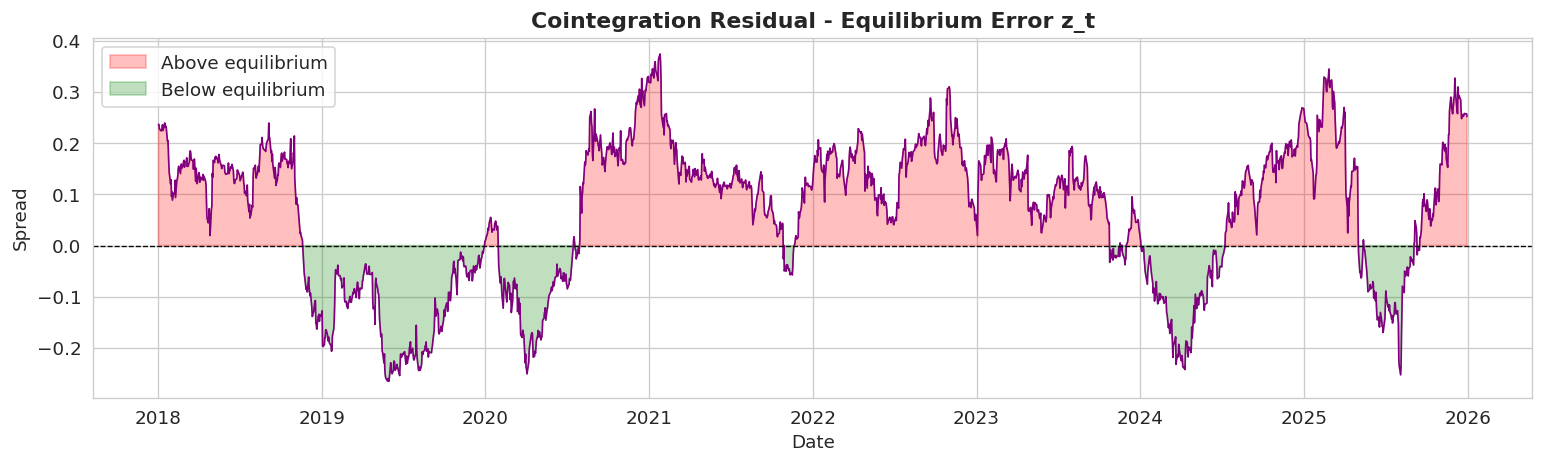

In [ ]:
# 7.3  Compute and plot the equilibrium error (spread) z_t = beta' * y_t
#      beta_hat shape is (n_rows, 1); first n_vars rows are asset weights,
#      remaining row(s) are the intercept from 'ci' specification.

beta_vec   = beta_hat[:n_vars, 0]          # asset weights only (length 3)
beta_const = beta_hat[n_vars:, 0] if beta_hat.shape[0] > n_vars else np.array([0.0])

# z_t = y_t @ beta_vec + const
spread_vals   = data_johansen.values @ beta_vec + beta_const.sum()
spread_series = pd.Series(spread_vals, index=data_johansen.index, name='Equilibrium Error')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(spread_series.index, spread_series, color='purple', linewidth=1)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.fill_between(spread_series.index, spread_series.values, 0,
                where=(spread_series.values > 0),
                alpha=0.25, color='red',   label='Above equilibrium')
ax.fill_between(spread_series.index, spread_series.values, 0,
                where=(spread_series.values < 0),
                alpha=0.25, color='green', label='Below equilibrium')
ax.set_title('Cointegration Residual - Equilibrium Error z_t', fontweight='bold')
ax.set_ylabel('Spread')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Diagnosis — Diagnostic Plots

In [ ]:
# 8.1  ADF test on the equilibrium error — confirms cointegration if stationary
adf_spread = adfuller(spread_series.dropna(), maxlag=20, autolag='AIC')

print('=== ADF Test on Equilibrium Error (Spread) ===')
print(f'  ADF statistic : {adf_spread[0]:.4f}')
print(f'  p-value       : {adf_spread[1]:.4f}')
print(f'  Lags used     : {adf_spread[2]}')
print(f'  1% CV         : {adf_spread[4]["1%"]:.3f}')
print(f'  5% CV         : {adf_spread[4]["5%"]:.3f}')
if adf_spread[1] < 0.05:
    print('  Conclusion    : STATIONARY — cointegration confirmed')
else:
    print('  Conclusion    : NON-STATIONARY — cointegration not supported')

=== ADF Test on Equilibrium Error (Spread) ===
  ADF statistic : -2.6823
  p-value       : 0.0772
  Lags used     : 7
  1% CV         : -3.434
  5% CV         : -2.863
  Conclusion    : NON-STATIONARY — cointegration not supported


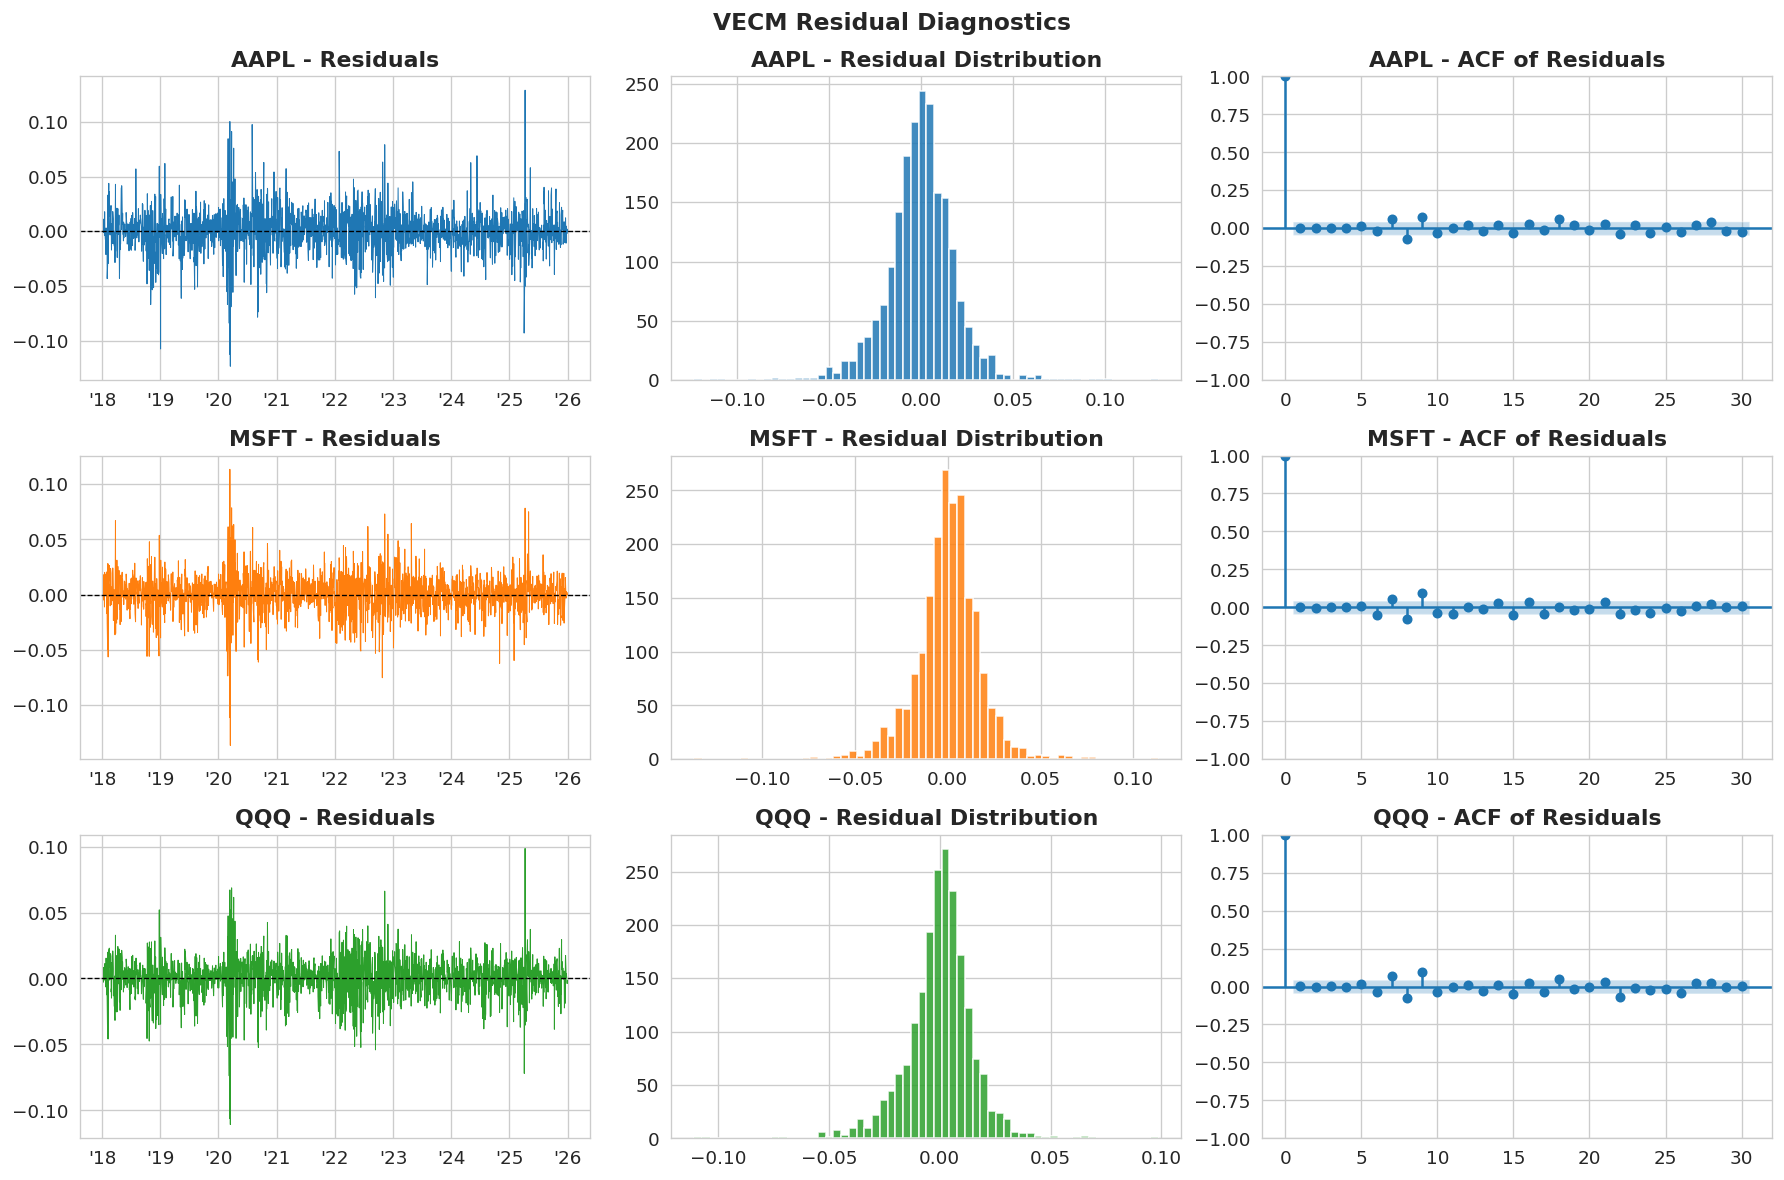

=== Durbin-Watson Statistics (target ~2.0) ===
  AAPL_resid: 1.9996
  MSFT_resid: 1.9990
  QQQ_resid: 1.9986


In [ ]:
# 8.2  VECM residual diagnostics
resid_array = vecm_fit.resid                          # shape: (T-k_ar_diff, 3)
resid_index = data_johansen.index[-resid_array.shape[0]:]
residuals   = pd.DataFrame(
    resid_array,
    index   = resid_index,
    columns = ['AAPL_resid', 'MSFT_resid', 'QQQ_resid']
)

fig, axes = plt.subplots(3, 3, figsize=(15, 10))

for i, col in enumerate(residuals.columns):
    ticker = col.split('_')[0]

    # Time-series plot
    axes[i, 0].plot(residuals.index, residuals[col], linewidth=0.6, color=COLORS[i])
    axes[i, 0].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[i, 0].set_title(f'{ticker} - Residuals', fontweight='bold')
    axes[i, 0].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))

    # Histogram
    axes[i, 1].hist(residuals[col], bins=60, color=COLORS[i], edgecolor='white', alpha=0.85)
    axes[i, 1].set_title(f'{ticker} - Residual Distribution', fontweight='bold')

    # ACF — do not pass unsupported 'color' kwarg
    plot_acf(residuals[col], ax=axes[i, 2], lags=30, alpha=0.05)
    axes[i, 2].set_title(f'{ticker} - ACF of Residuals', fontweight='bold')

plt.suptitle('VECM Residual Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== Durbin-Watson Statistics (target ~2.0) ===')
for col in residuals.columns:
    dw = durbin_watson(residuals[col])
    print(f'  {col}: {dw:.4f}')

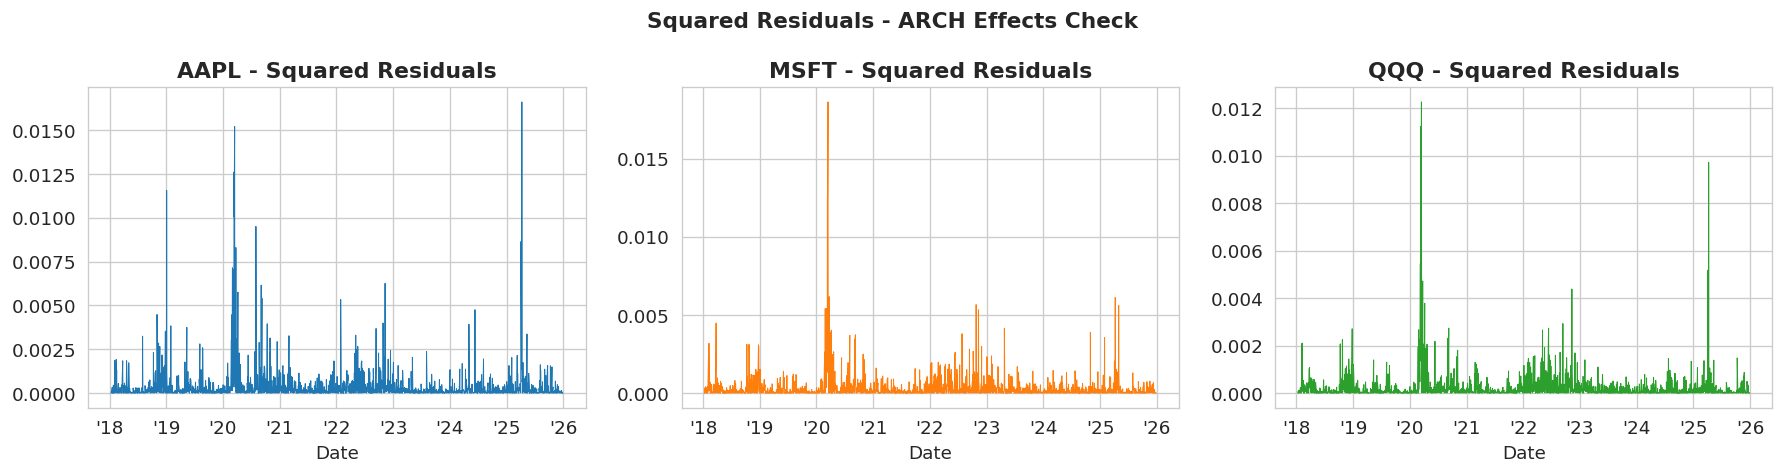

In [ ]:
# 8.3  Squared residuals — ARCH / heteroskedasticity check
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(residuals.columns):
    ticker = col.split('_')[0]
    axes[i].plot(residuals.index, residuals[col] ** 2,
                 linewidth=0.6, color=COLORS[i])
    axes[i].set_title(f'{ticker} - Squared Residuals', fontweight='bold')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("'%y"))
    axes[i].set_xlabel('Date')

plt.suptitle('Squared Residuals - ARCH Effects Check', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Damage — Problems the Model Reveals

The diagnostic plots allow us to assess several challenges identified in the group handbook:

| Challenge | Evidence | Assessment |
|-----------|----------|------------|
| **Heteroskedasticity (ARCH effects)** | Squared residuals cluster around high-volatility periods (COVID-19 crash 2020, rate-hike cycle 2022). | Volatility is time-varying; a GARCH-VECM extension may be warranted. |
| **Structural breaks** | Coefficient instability is likely given the 2020 pandemic shock and 2022 Fed tightening. | Rolling estimation or a Markov-switching VECM could capture regime changes. |
| **Fat tails / Non-normality** | Residual histograms show excess kurtosis; standard errors may be underestimated. | Robust standard errors (HAC) or bootstrapped inference advised. |
| **Lag selection sensitivity** | Using AIC vs BIC may suggest different optimal lag lengths, affecting alpha estimates. | Test robustness across lag specifications. |
| **Parameter instability** | The adjustment speed alpha may differ pre- and post-COVID. | Chow test or recursive estimation can check stability. |
| **Omitted common factors** | The three-asset system may miss macro variables (e.g., Fed funds rate, VIX). | Augmenting the VECM with exogenous macro variables may improve fit. |

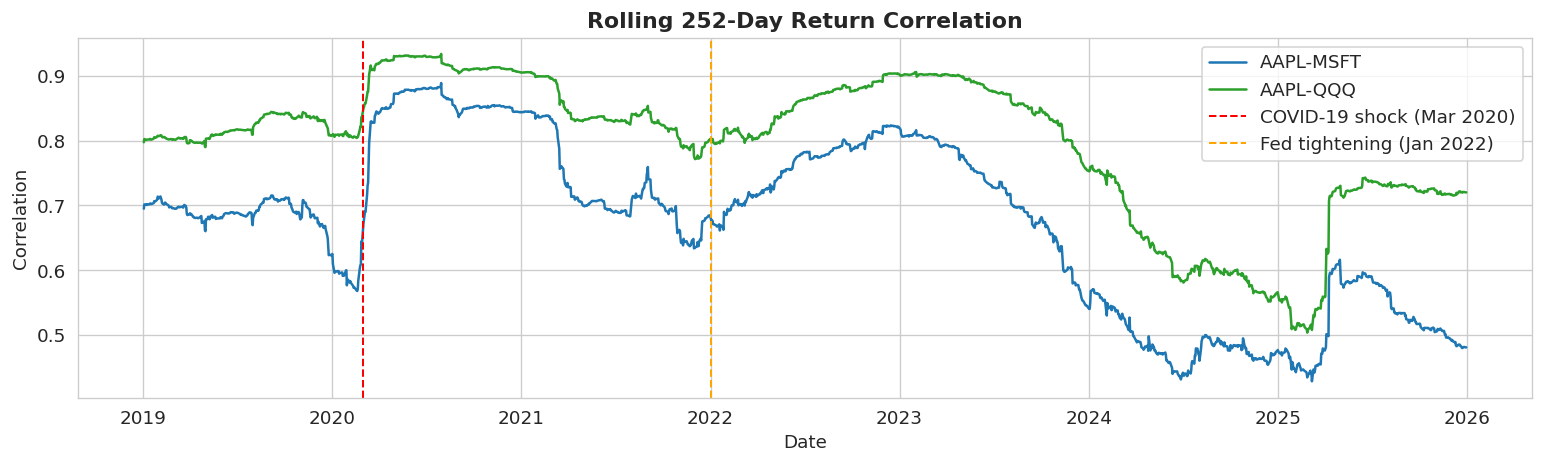

In [ ]:
# 9.1  Rolling 252-day correlation — structural stability check
roll_aapl_msft = log_returns['AAPL'].rolling(252).corr(log_returns['MSFT'])
roll_aapl_qqq  = log_returns['AAPL'].rolling(252).corr(log_returns['QQQ'])

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(roll_aapl_msft.index, roll_aapl_msft, label='AAPL-MSFT', color='#1f77b4')
ax.plot(roll_aapl_qqq.index,  roll_aapl_qqq,  label='AAPL-QQQ',  color='#2ca02c')
ax.axvline(pd.Timestamp('2020-03-01'), color='red',    linestyle='--',
           linewidth=1.2, label='COVID-19 shock (Mar 2020)')
ax.axvline(pd.Timestamp('2022-01-01'), color='orange', linestyle='--',
           linewidth=1.2, label='Fed tightening (Jan 2022)')
ax.set_title('Rolling 252-Day Return Correlation', fontweight='bold')
ax.set_ylabel('Correlation')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout()
plt.show()

---
## 10. Directions — Model Improvements

Although the VECM captures the long-run equilibrium, the diagnostics suggest several refinements:

1. **Shorten the time horizon** — Estimating the VECM on sub-periods (e.g., 2018–2019, 2021–2025) may yield more stable parameters, avoiding regime contamination from the COVID shock.

2. **Add macro controls** — Including the CBOE VIX, 10-year Treasury yield, or USD index as exogenous regressors can reduce residual autocorrelation.

3. **GARCH-VECM** — To account for time-varying volatility, the residuals of each equation could be modelled with a GARCH(1,1), giving conditional heteroskedasticity-consistent inference.

4. **Markov-Switching VECM** — Given the rolling-correlation instability, a two-regime MS-VECM (normal vs. crisis) may better capture adjustment dynamics across market conditions.

5. **Increase the asset universe** — Adding Google (GOOGL) or Amazon (AMZN) may reveal additional cointegrating vectors and reduce model risk from omitted common factors.

=== Alpha Stability Across Sub-Periods ===
        Pre-COVID (2018-Feb 2020)  Post-COVID (Jun 2020-2025)
d_AAPL                  -0.003288                   -0.021148
d_MSFT                  -0.002017                   -0.012750
d_QQQ                    0.005427                   -0.013791


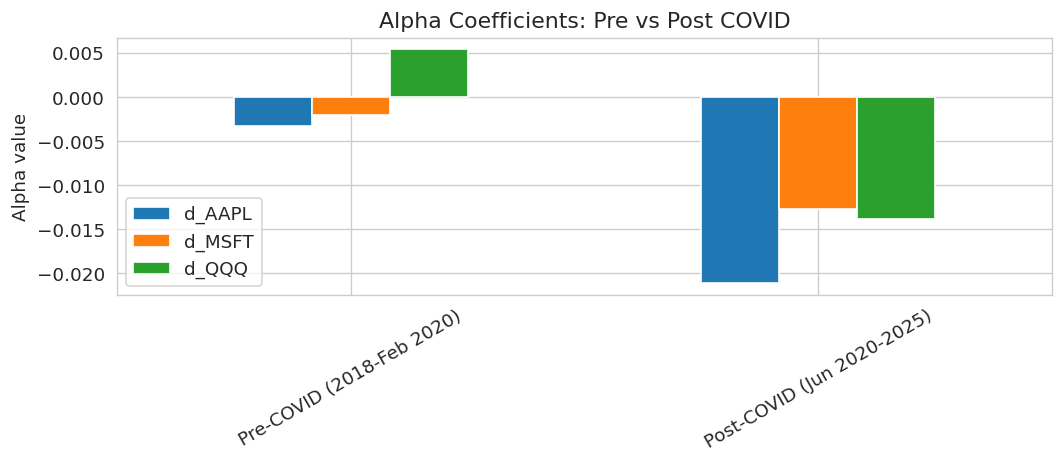

In [ ]:
# 10.1  Sub-period stability: compare pre-COVID vs post-COVID VECM alpha
pre_covid  = data_johansen.loc[:'2020-02-28']
post_covid = data_johansen.loc['2020-06-01':]

results_stability = {}
for label, sub in [('Pre-COVID (2018-Feb 2020)', pre_covid),
                    ('Post-COVID (Jun 2020-2025)', post_covid)]:
    if len(sub) > 50:   # need enough observations
        m = VECM(sub, k_ar_diff=4, coint_rank=1, deterministic='ci').fit()
        results_stability[label] = m.alpha.flatten()

stab_df = pd.DataFrame(results_stability, index=['d_AAPL', 'd_MSFT', 'd_QQQ'])
print('=== Alpha Stability Across Sub-Periods ===')
print(stab_df.round(6))

stab_df.T.plot(kind='bar', figsize=(9, 4), title='Alpha Coefficients: Pre vs Post COVID')
plt.ylabel('Alpha value')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

---
## 11. Deployment — Practical Applications

### 11.1 Statistical Arbitrage (Pairs Trading)
The equilibrium error $z_t = \\beta' y_t$ is the **tradeable spread**. A quantitative trading strategy would:
1. **Enter long AAPL / short MSFT** when $z_t$ falls below $-2\\sigma_z$ (spread too wide; convergence expected).
2. **Exit** when $z_t$ reverts to near zero.
3. Use $\\hat{\\alpha}$ (adjustment speed) to calibrate expected holding period.

### 11.2 Risk Management
Portfolio managers holding AAPL, MSFT, and QQQ can use the VECM to:
- Estimate short-run vs. long-run variance decomposition.
- Identify which asset absorbs disequilibrium (the one with the largest |alpha| is the adjuster).
- Build hedge ratios directly from the cointegrating vector beta.

### 11.3 Forecasting
The VECM generates multi-step-ahead forecasts that respect the long-run equilibrium constraint, preventing prices from diverging permanently — a key advantage over unrestricted VAR models when cointegration is present.

### 11.4 Index Replication
The cointegrating vector guides **synthetic index construction**: using AAPL and MSFT alone to replicate QQQ exposure with lower transaction costs than buying the ETF directly.

---

## References

- Engle, R. F., & Granger, C. W. J. (1987). Co-integration and error correction: Representation, estimation, and testing. *Econometrica*, 55(2), 251–276.
- Johansen, S. (1991). Estimation and hypothesis testing of cointegration vectors in Gaussian vector autoregressive models. *Econometrica*, 59(6), 1551–1580.
- Tsay, R. S. (2010). *Analysis of Financial Time Series* (3rd ed.). Wiley.
- Yahoo Finance. (2025). Apple Inc. (AAPL) Historical Data. https://finance.yahoo.com/quote/AAPL/history/
- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media.